# 03_How_The_Algorithm_Works.ipynb

---

# Step-by-Step Workflow

Let's understand exactly how Ridge Regression works from receiving data to making predictions.

```text
            Training Dataset
                    │
                    ▼
        Split Features(X) and Target(y)
                    │
                    ▼
          Feature Scaling (Important)
                    │
                    ▼
        Initialize Model Parameters
          (Weights and Bias)
                    │
                    ▼
      Compute Predictions (ŷ = XW + b)
                    │
                    ▼
      Compute Ridge Loss Function
 (Prediction Error + L2 Regularization)
                    │
                    ▼
     Optimize Weights (Reduce Loss)
                    │
                    ▼
          Repeat Until Convergence
                    │
                    ▼
          Save Final Model
                    │
                    ▼
          Predict New Samples
```

---

# Step 1: Collect Training Data

Suppose we want to predict house prices.

| Area | Bedrooms | Price |
| ---: | -------: | ----: |
| 1000 |        2 |    40 |
| 1200 |        2 |    48 |
| 1500 |        3 |    61 |
| 1700 |        3 |    69 |
| 2000 |        4 |    80 |

Here,

Features:

```text
X =
Area
Bedrooms
```

Target:

```text
y = Price
```

---

# Step 2: Feature Scaling

Unlike Linear Regression, Ridge Regression **must** scale features.

Suppose

| Feature |  Value |
| ------- | -----: |
| Age     |     30 |
| Income  | 800000 |

Without scaling,

Income dominates because of its larger numerical values.

After StandardScaler:

| Feature | Value |
| ------- | ----: |
| Age     | -0.54 |
| Income  |  0.61 |

Now both contribute equally to the penalty.

---

# Step 3: Initialize Parameters

Initially,

```text
Weight₁ = 0
Weight₂ = 0
Bias = 0
```

The model has learned nothing yet.

---

# Step 4: Make Predictions

For every training sample,

Prediction is

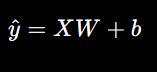

Example

Suppose

```text
Area = 1500
Bedrooms = 3

Weight_area = 0.02
Weight_bedroom = 5

Bias = 10
```

Prediction

```text
Price

= (1500 × 0.02)

+ (3 × 5)

+10

=30+15+10

=55
```

---

# Step 5: Compute Prediction Error

Now compare prediction with actual value.

Actual

```text
61
```

Prediction

```text
55
```

Error

```text
61−55=6
```

All sample errors are combined into the Mean Squared Error (MSE).

---

# Step 6: Add Ridge Penalty

Instead of minimizing only prediction error,

Ridge adds another term.

Conceptually,

```text
Total Loss

=

Prediction Error

+

Penalty
```

Penalty depends on coefficient sizes.

Example

Suppose

```text
Weights

8

−4

6
```

Penalty

```text
8²+(-4)²+6²

=

64+16+36

=

116
```

Large weights produce a larger penalty.

---

# Step 7: Update Weights

Optimization algorithm (Gradient Descent or Closed-form Solution)

tries to reduce

* prediction error
* coefficient size

simultaneously.

Example

Iteration 1

```text
Weights

8

−4

6
```

↓

Iteration 2

```text
6.5

−3.2

5
```

↓

Iteration 3

```text
5.7

−2.9

4.4
```

Weights gradually shrink while maintaining good predictions.

---

# Step 8: Stop Training

Training stops when

* loss stops decreasing
* maximum iterations reached
* convergence achieved

Final model

```text
Weights

5.4

−2.8

4.1
```

These are stored.

---

# Training Process

The complete training procedure is:

```text
Start

↓

Read Dataset

↓

Scale Features

↓

Initialize Weights

↓

Predict Output

↓

Calculate Prediction Error

↓

Calculate Ridge Penalty

↓

Combine Both Losses

↓

Optimize Weights

↓

Converged?

↓

No → Repeat

↓

Yes

↓

Save Model
```

---

## Pseudo Code

```python
Initialize weights

repeat until convergence:

    predictions = X @ weights + bias

    prediction_error = MSE(y, predictions)

    regularization_penalty = alpha * sum(weights²)

    total_loss = prediction_error + regularization_penalty

    update weights

save weights
```

---

# Prediction Process

Once training finishes,

prediction becomes very simple.

```text
New Sample

↓

Scale using SAME scaler

↓

Multiply with learned coefficients

↓

Add Bias

↓

Return Prediction
```

Example

Training learned

```text
Area Weight = 0.025

Bedroom Weight = 4

Bias = 8
```

New house

```text
Area =1800

Bedrooms =3
```

Prediction

```text
Price

=(1800×0.025)

+(3×4)

+8

=45+12+8

=65
```

No regularization happens during prediction.

Regularization is **only used during training**.

---

# Flow Diagram

```text
                    Training

          Dataset (X , y)
                │
                ▼
          Feature Scaling
                │
                ▼
      Initialize Weights
                │
                ▼
         Compute Prediction
                │
                ▼
     Compute Prediction Error
                │
                ▼
     Compute L2 Penalty
                │
                ▼
     Total Ridge Loss
                │
                ▼
      Optimize Parameters
                │
                ▼
      Final Coefficients
                │
                ▼
           Save Model

──────────────────────────────────────

             Prediction

         New Sample

              │

              ▼

      Same Feature Scaling

              │

              ▼

     Multiply by Coefficients

              │

              ▼

          Add Bias

              │

              ▼

        Final Prediction
```

---

# Small Numerical Example

Suppose we have one feature:

| Hours Studied | Marks |
| ------------: | ----: |
|             1 |    45 |
|             2 |    50 |
|             3 |    60 |

Assume after training,

```text
Weight =6

Bias =40
```

Predict

For

```text
Hours=2
```

Prediction

```text
=2×6+40

=52
```

Actual

```text
50
```

Error

```text
2
```

Now suppose another possible model has

```text
Weight=20

Bias=10
```

Prediction

```text
=2×20+10

=50
```

Training error is smaller for this point, but the coefficient is much larger.

Ridge prefers the first model because it balances:

* reasonable prediction error
* smaller coefficients

This often leads to better performance on unseen data.

---

# Visualization of Working

Imagine the model is trying to fit the data.

### Ordinary Linear Regression

```text
Price

^

|

|                 *

|             *

|         *

|     *

|  *

+---------------------------->

        Area
```

The line may become steep to fit every training point.

---

### Ridge Regression

```text
Price

^

|

|             *

|         *

|      *

|    *

| *

+---------------------------->

        Area
```

The fitted line is slightly smoother and less influenced by noisy points.

---

## Effect on Coefficients

Before Ridge

```text
Feature A : 12.4

Feature B : -9.6

Feature C : 7.2
```

↓

After Ridge

```text
Feature A : 8.3

Feature B : -6.8

Feature C : 5.4
```

Notice:

* Signs remain the same.
* Magnitudes decrease.
* No coefficient becomes exactly zero.

---

# Algorithm Summary

### Ridge Regression Algorithm

1. Collect training data.
2. Separate features (**X**) and target (**y**).
3. Scale the features (typically with `StandardScaler`).
4. Initialize weights and bias.
5. Compute predictions using the linear equation.
6. Calculate the prediction error (MSE).
7. Add the **L2 regularization penalty** based on the squared coefficients.
8. Optimize the weights to minimize the combined loss.
9. Repeat until convergence.
10. Save the learned coefficients and bias.
11. For new data, apply the same feature scaling and use the learned model to make predictions.

---

## Key Takeaways

* Ridge Regression follows the **same overall workflow as Linear Regression**, with one crucial difference:

  * During **training**, it adds an **L2 penalty** to discourage large coefficients.
* **Regularization affects only the training process**. Prediction uses the learned coefficients without any penalty calculation.
* **Feature scaling is mandatory** because the penalty depends on coefficient magnitudes.
* The result is a model that is generally **more stable, less prone to overfitting, and better at handling multicollinearity**.

---